In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression

In [2]:
from utils import DataHandler
from ESN import ESNetwork, ClassicalRC
from reservoirs import CPRC
from circuits import CPCircuit

In [3]:
train = pd.read_csv("DailyDelhiClimateTrain.csv",parse_dates=["date"], index_col="date").sort_index(inplace=False)
test = pd.read_csv("DailyDelhiClimateTest.csv",parse_dates=["date"], index_col="date").sort_index(inplace=False)

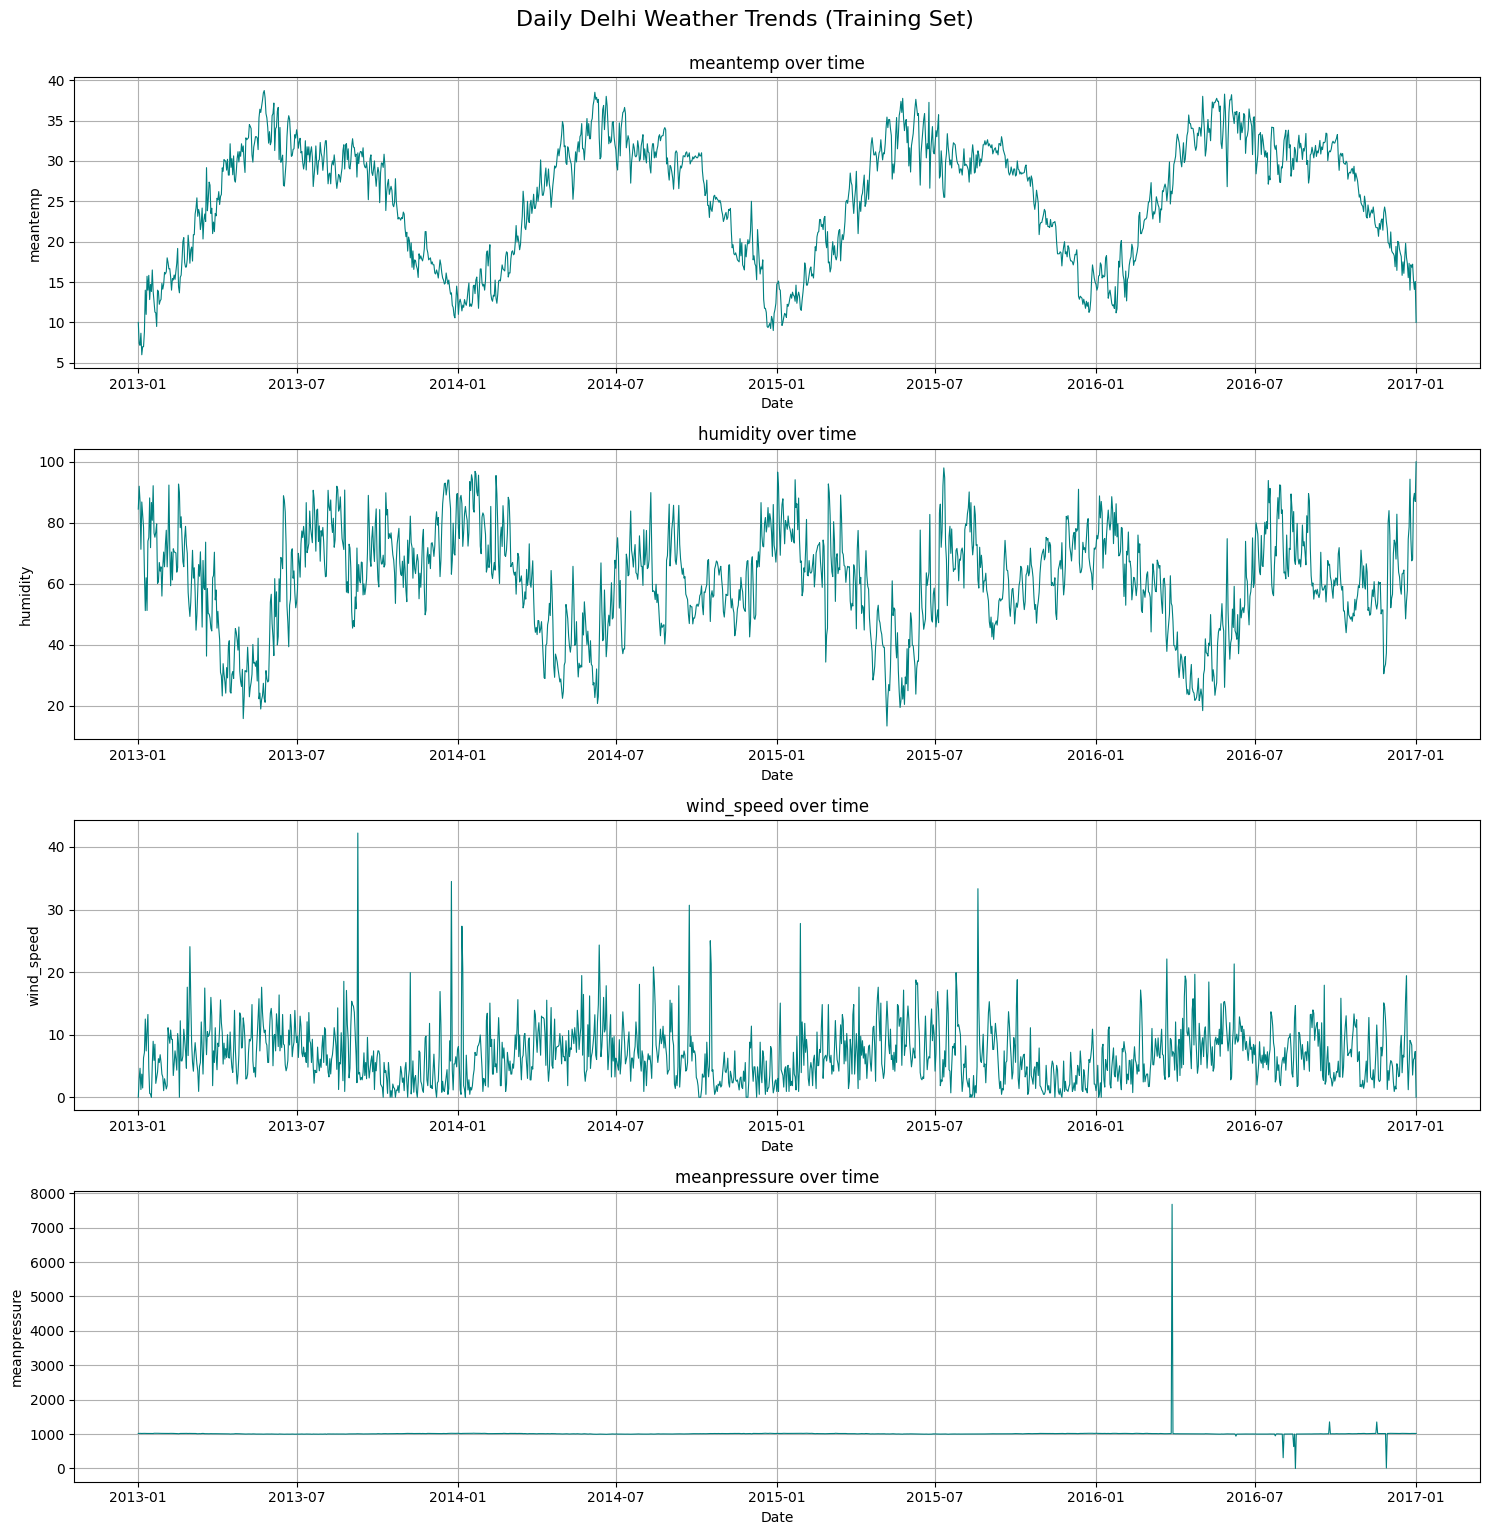

In [4]:
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

# Plot settings
plt.figure(figsize=(15, 15))

for i, col in enumerate(features):
    plt.subplot(4, 1, i + 1)
    plt.plot(train.index, train[col], color='teal', linewidth=0.8)
    plt.title(f"{col} over time", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Daily Delhi Weather Trends (Training Set)", fontsize=16, y=1.02)
plt.show()

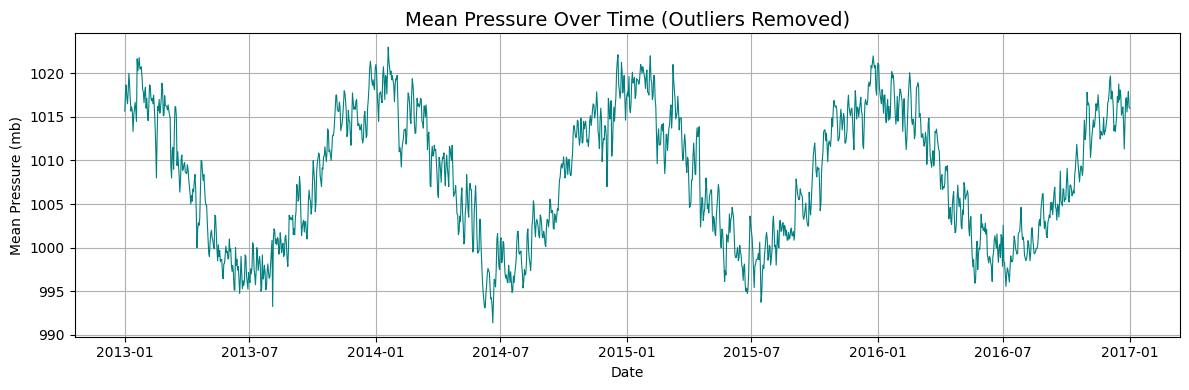

In [5]:
# Calculate Inter Quatile Range(IQR) for meanpressure
Q1 = train['meanpressure'].quantile(0.25)
Q3 = train['meanpressure'].quantile(0.75)
IQR = Q3 - Q1

#  Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#  Filter out the outliers
filtered_pressure = train[(train['meanpressure'] >= lower_bound) & (train['meanpressure'] <= upper_bound)]

#  Replot the cleaned pressure values
plt.figure(figsize=(12, 4))
plt.plot(filtered_pressure.index, filtered_pressure['meanpressure'], color='teal', linewidth=0.8)
plt.title("Mean Pressure Over Time (Outliers Removed)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Mean Pressure (mb)")
plt.grid(True)
plt.tight_layout()
plt.show()

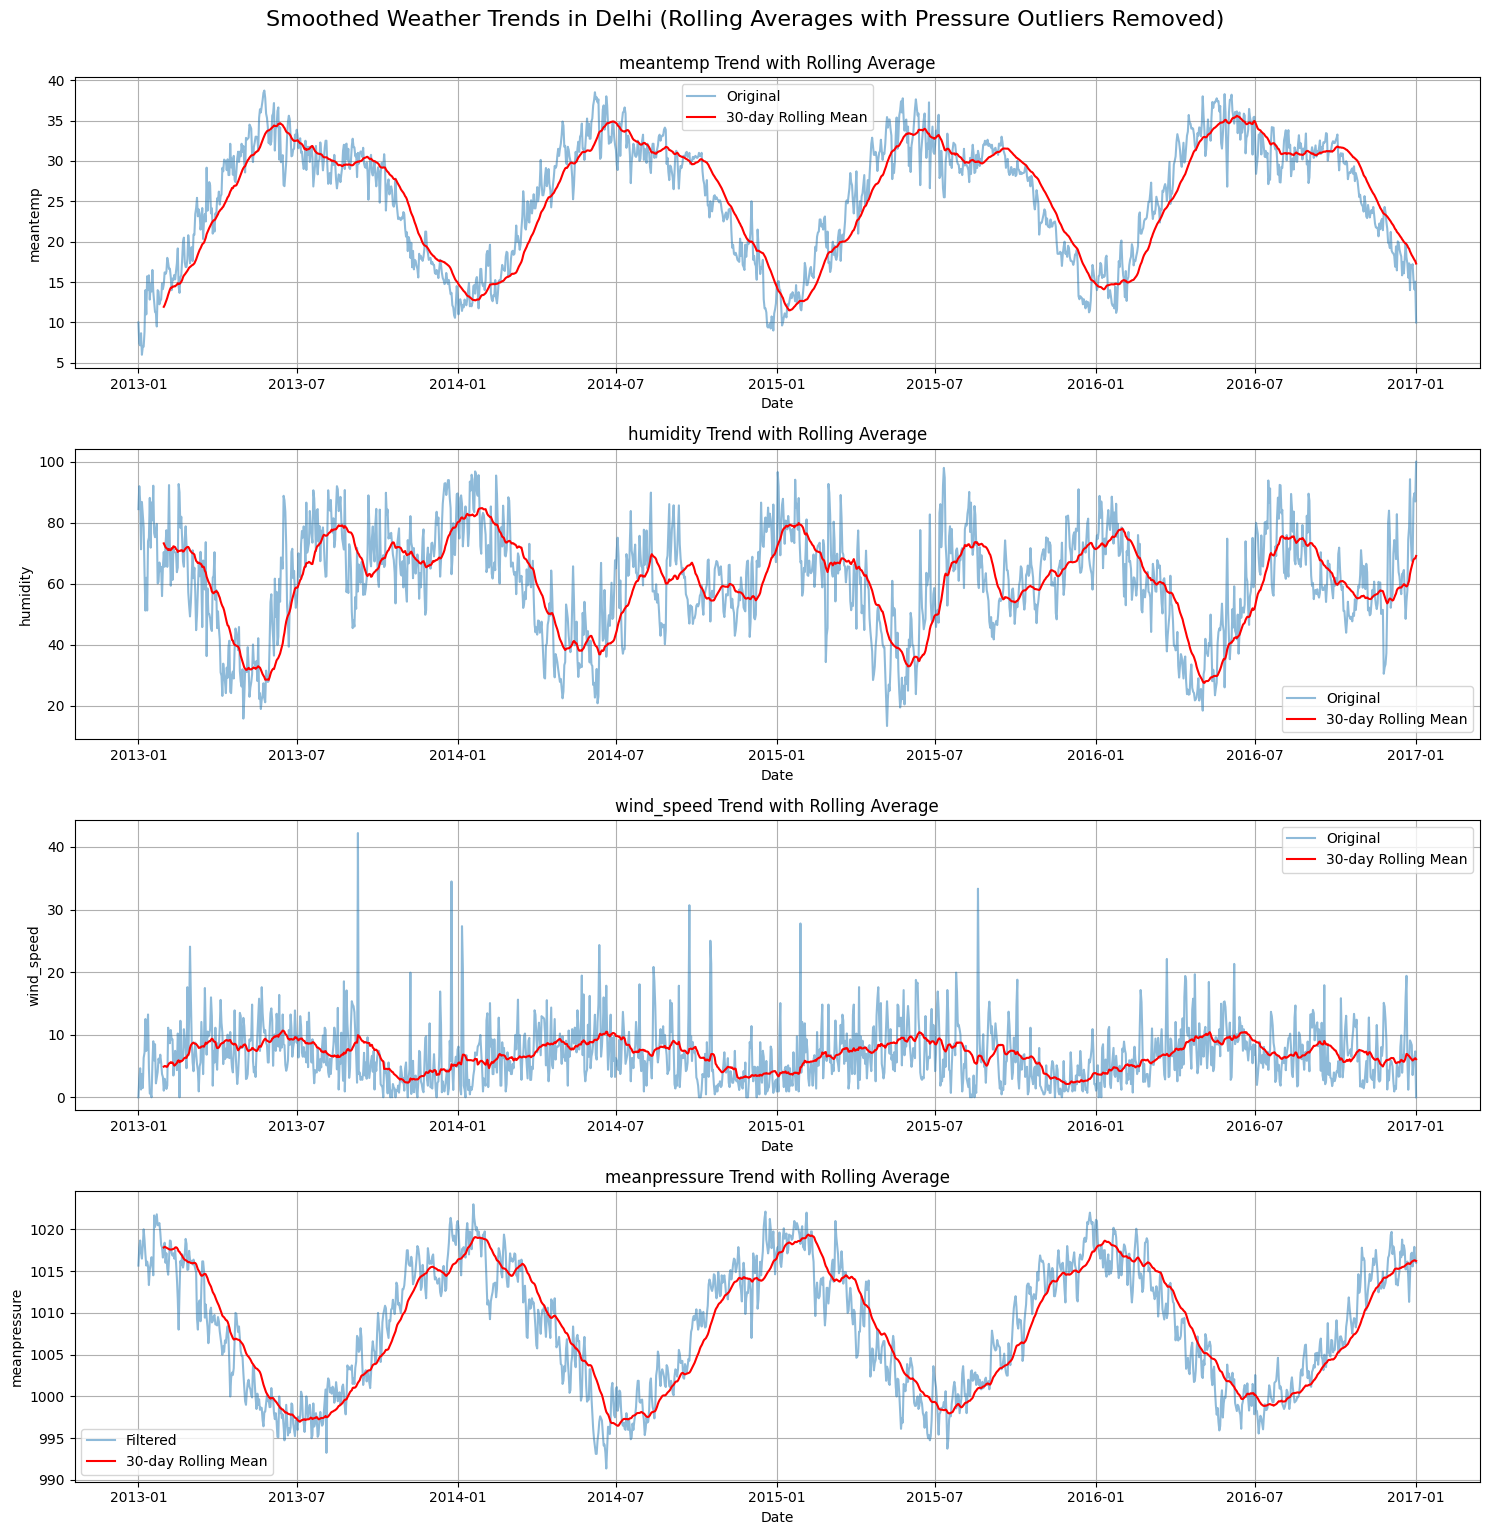

In [6]:
plt.figure(figsize=(15, 15))
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']


for i, col in enumerate(features):
    plt.subplot(4, 1, i + 1)

    if col == 'meanpressure':
        plt.plot(filtered_pressure.index, filtered_pressure[col], label='Filtered', alpha=0.5)
        plt.plot(filtered_pressure[col].rolling(window=30).mean(), label='30-day Rolling Mean', color='red')
    else:
        plt.plot(train[col], label='Original', alpha=0.5)
        plt.plot(train[col].rolling(window=30).mean(), label='30-day Rolling Mean', color='red')

    plt.title(f"{col} Trend with Rolling Average", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Smoothed Weather Trends in Delhi (Rolling Averages with Pressure Outliers Removed)", fontsize=16, y=1.02)
plt.show()

In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[features])
test_scaled = scaler.transform(test[features])

In [8]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])
    return np.array(X), np.array(y)

In [9]:
def create_test_sequences(train_tail, test_data, seq_length):
    full = np.concatenate([train_tail[-seq_length:], test_data], axis=0)
    X = []
    for i in range(len(test_data)):
        X.append(full[i:i+seq_length])
    return np.array(X)

In [10]:
SEQ_LEN = 7
X_train_, y_train = create_sequences(train_scaled, SEQ_LEN)

In [11]:
X_test_ = create_test_sequences(train_scaled, test_scaled, SEQ_LEN)
X_train__ = X_train_.reshape((X_train_.shape[0], SEQ_LEN, len(features)))
X_test__ = X_test_.reshape((X_test_.shape[0], SEQ_LEN, len(features)))

y_test = test_scaled[:, 0]  # Column 0 = meantemp
y_test = y_test[:X_test__.shape[0]]

In [12]:
X_train = [sample.flatten() for sample in X_train__]
X_test = [sample.flatten() for sample in X_test__]

In [13]:
X_train[1]

array([0.04279476, 0.90759076, 0.07058266, 0.132881  , 0.0356623 ,
       0.84983498, 0.10974262, 0.13299381, 0.08151383, 0.66886689,
       0.02921206, 0.13279856, 0.        , 0.84790979, 0.08763619,
       0.13271178, 0.03056769, 0.80132013, 0.03505448, 0.13290703,
       0.03056769, 0.75280528, 0.14921838, 0.13316737, 0.08733624,
       0.58085809, 0.16918184, 0.13300001])

In [14]:
window_size = SEQ_LEN*4

In [15]:
cprc = CPRC(dim=window_size, execution_mode='simulation', kernel = True) #simulation
esn = ESNetwork(
    reservoir=cprc,
    dim=window_size,
    regularization=1e-6,
    alpha=0.2,
    show_progress=True,
    approach='feedback', # 'feedback', or 'time-multiplexing'
    model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
    limit = 0.6,
    cpk=True)

In [16]:
esn.fit(X_train, y_train)

Training Progress: 100%|███████████████| 1455/1455 [25:12<00:00,  1.04s/ sample]


In [17]:
predictions = esn.predict(X_test)
rmse = mean_squared_error(y_test, predictions)
print(rmse)

Prediction Progress: 100%|███████████████| 114/114 [02:04<00:00,  1.09s/ sample]

0.003115629605728981


Quantum ESN RMSE: 0.0558


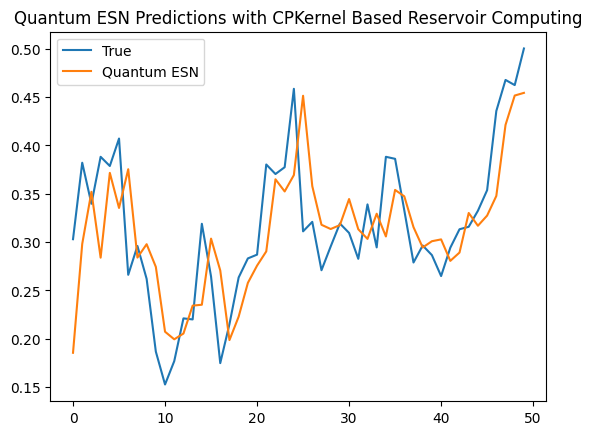

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Quantum ESN RMSE: {rmse:.4f}")
a = 0
b = 50
# Plot Predictions
plt.plot(y_test[a:a+b], label="True")
plt.plot(predictions[a:a+b], label="Quantum ESN")
plt.title("Quantum ESN Predictions with CPKernel Based Reservoir Computing")
plt.legend()
plt.show()

Quantum ESN RMSE: 0.0774


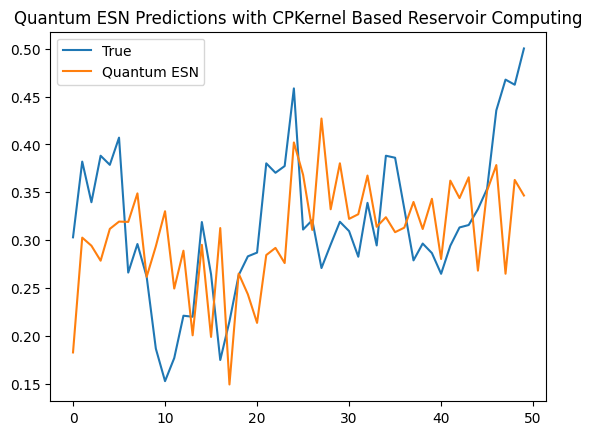

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Quantum ESN RMSE: {rmse:.4f}")
a = 0
b = 50
# Plot Predictions
plt.plot(y_test[a:a+b], label="True")
plt.plot(predictions[a:a+b], label="Quantum ESN")
plt.title("Quantum ESN Predictions with CPKernel Based Reservoir Computing")
plt.legend()
plt.show()

In [ ]:
## 0.009914412163077074   --5
## 0.007975713332019052   --6
## 0.005064294133049157   --7
## 0.005533937952776357   --8

In [19]:
itr = 10
a= 0.1
b = 1
vals = np.linspace(a,b,itr)

In [24]:
from joblib import Parallel, delayed
from tqdm import tqdm
dim = len(X_train[0])
def run_esn(i, alpha_val):
    cprc = CPRC(dim=window_size, execution_mode='simulation', kernel = True)
    esn = ESNetwork(
        reservoir=cprc,
        dim=window_size,
        regularization=1e-6,
        alpha=alpha_val,
        show_progress=False,  # disable internal tqdm
        approach='feedback',
        model_type='ridge',
        limit=0.6,
        cpk=True
    )
    esn.fit(X_train, y_train)
    preds = esn.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    return mse, preds

In [27]:
base_seed = 42
results = Parallel(n_jobs=-1)(
    delayed(run_esn)(i, vals[i]) for i in tqdm(range(itr), desc="ESN Runs")
)

# Unpack results
mses, predictions = zip(*results)
mses = list(mses)
predictions = list(predictions)

# Optional: print best MSE
print("Best MSE:", min(mses))


ESN Runs: 100%|█████████████████████████████████| 10/10 [00:00<00:00, 38.77it/s]


Best MSE: 0.003115629605494837


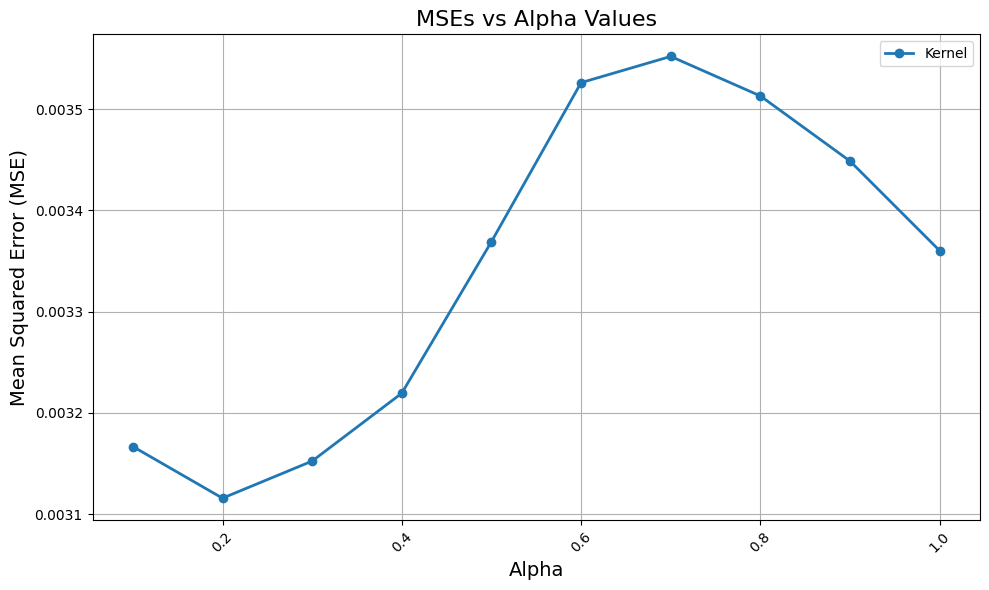

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(vals, mses, marker='o', linestyle='-', linewidth=2, label="Kernel")
# plt.plot(vals, mses2, marker='x', linestyle='--', linewidth=2, label="Kernel")

plt.title("MSEs vs Alpha Values", fontsize=16)
plt.xlabel("Alpha", fontsize=14)
plt.ylabel("Mean Squared Error (MSE)", fontsize=14)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [66]:
from ESN import ClassicalRC
CRM = ClassicalRC(input_size=len(X_train[0]), reservoir_size=150, spectral_radius=0.6, sparsity=0.1,noise=0.0001,use_reservoir=True)
CRM.train(np.array(X_train), y_train, model_type="ridge")

In [68]:
y_pred = CRM.predict(np.array(X_test))
mse = CRM.evaluate(np.array(X_test), y_test)
print("MSE:", mse, "RMSE:", np.sqrt(mse))

MSE: 0.0026789279003219895 RMSE: 0.051758360680396256
